# Exploration & Visualisations — Bénin Insights Challenge
**Source** : BigQuery `gdelt-494812.benin_2025`  
**Tables utilisées** : `events_clean`, `mentions_clean`, `gkg_clean`

Ce notebook charge les données directement depuis BigQuery et produit toutes les visualisations du projet.

## 0. Imports & connexion BigQuery

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from google.cloud import bigquery

PROJECT  = 'gdelt-494812'
DATASET  = 'benin_2025'
client   = bigquery.Client(project=PROJECT)

def bq(sql):
    """Raccourci : exécute une requête et retourne un DataFrame."""
    return client.query(sql).to_dataframe()

print('Connexion OK')

C:\Python313\Lib\site-packages\google\auth\_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Connexion OK


## 1. Chargement des tables

> On inspecte d'abord le schéma réel pour adapter les noms de colonnes.

In [2]:
# ── Inspecter les colonnes disponibles ───────────────────────────────────────
for table in ['events_clean', 'mentions_clean', 'gkg_clean']:
    ref = client.get_table(f'{PROJECT}.{DATASET}.{table}')
    cols = [f.name for f in ref.schema]
    print(f'\n{table} ({len(cols)} colonnes) :')
    print(', '.join(cols))


events_clean (39 colonnes) :
GLOBALEVENTID, DATEADDED, SQLDATE, MonthYear, Year, Actor1Name, Actor1CountryCode, Actor1Type1Code, Actor2Name, Actor2CountryCode, Actor2Type1Code, IsRootEvent, EventCode, EventBaseCode, EventRootCode, QuadClass, GoldsteinScale, NumMentions, NumSources, NumArticles, AvgTone, ActionGeo_FullName, ActionGeo_CountryCode, ActionGeo_ADM1Code, ActionGeo_Lat, ActionGeo_Long, SOURCEURL, date_clean, year_month_clean, QuadClass_Label, interaction_type, EventCategory, Actor1Role, Actor2Role, goldstein_category, tone_category, has_international_actor, event_scope, is_significant

mentions_clean (15 colonnes) :
GLOBALEVENTID, MentionTimeDate, MentionType, MentionSourceName, Confidence, MentionDocTone, MentionDocTranslationInfo, mention_datetime, mention_date, mention_year_month, MentionType_Label, tone_category, confidence_level, source_language, is_translated

gkg_clean (28 colonnes) :
GKGRECORDID, DATE, SourceCommonName, DocumentIdentifier, V2Themes, V2Locations, V2Pe

In [3]:
# ── Charger events_clean ─────────────────────────────────────────────────────
# ADAPTE les noms de colonnes ci-dessous si nécessaire après avoir vu le schéma
SQL_EVENTS = f"""
SELECT *
FROM `{PROJECT}.{DATASET}.events_clean`
LIMIT 100000
"""
events = bq(SQL_EVENTS)
print(f'events_clean : {len(events):,} lignes, {events.shape[1]} colonnes')
events.head(3)

events_clean : 31,504 lignes, 39 colonnes


,GLOBALEVENTID,DATEADDED,SQLDATE,MonthYear,Year,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Name,Actor2CountryCode,...,QuadClass_Label,interaction_type,EventCategory,Actor1Role,Actor2Role,goldstein_category,tone_category,has_international_actor,event_scope,is_significant
0,1221339362,20250118064500,20250118,202501,2025,ECOWAS,WAF,IGO,None,None,...,Verbal Cooperation,Cooperation,Make Public Statement,Intergovernmental Org,None,Neutral,Negative,False,Unknown,True
1,1220702354,20250115101500,20250115,202501,2025,ECOWAS,WAF,IGO,BENIN,BEN,...,Verbal Cooperation,Cooperation,Make Public Statement,Intergovernmental Org,Government,Neutral,Very Negative,False,International,True
2,1274392218,20251115230000,20251115,202511,2025,AFRICA,AFR,None,UNITED STATES,USA,...,Verbal Cooperation,Cooperation,Make Public Statement,None,None,Neutral,Negative,True,Unknown,True


In [4]:
# ── Identifier automatiquement les colonnes clés ─────────────────────────────
# Le script cherche les colonnes par mot-clé pour s'adapter aux noms enrichis

def find_col(df, keywords):
    """Retourne le nom de la première colonne dont le nom contient un des mots-clés."""
    for kw in keywords:
        for c in df.columns:
            if kw.lower() in c.lower():
                return c
    return None

COL_DATE      = find_col(events, ['date', 'sqldate', 'eventdate'])
COL_TONE      = find_col(events, ['tone', 'avgtone', 'avg_tone'])
COL_GOLDSTEIN = find_col(events, ['goldstein', 'gold'])
COL_QUADCLASS = find_col(events, ['quadclass', 'quad_class', 'eventtype', 'category'])
COL_ACT1      = find_col(events, ['actor1name', 'actor1', 'act1_name'])
COL_ACT2      = find_col(events, ['actor2name', 'actor2', 'act2_name'])
COL_LAT       = find_col(events, ['lat', 'latitude'])
COL_LON       = find_col(events, ['lon', 'long', 'longitude'])
COL_LOCATION  = find_col(events, ['location', 'fullname', 'geo_name', 'city'])
COL_MENTIONS  = find_col(events, ['nummentions', 'mentions', 'num_mentions'])
COL_ARTICLES  = find_col(events, ['numarticles', 'articles', 'num_articles'])
COL_URL       = find_col(events, ['sourceurl', 'url', 'source'])

print('Colonnes identifiées :')
for k, v in {
    'Date': COL_DATE, 'Tone': COL_TONE, 'Goldstein': COL_GOLDSTEIN,
    'QuadClass': COL_QUADCLASS, 'Actor1': COL_ACT1, 'Actor2': COL_ACT2,
    'Lat': COL_LAT, 'Lon': COL_LON, 'Location': COL_LOCATION,
    'Mentions': COL_MENTIONS, 'Articles': COL_ARTICLES, 'URL': COL_URL
}.items():
    status = v if v else '*** NON TROUVEE — a corriger manuellement ***'
    print(f'  {k:12s} -> {status}')

Colonnes identifiées :
  Date         -> DATEADDED
  Tone         -> AvgTone
  Goldstein    -> GoldsteinScale
  QuadClass    -> QuadClass
  Actor1       -> Actor1Name
  Actor2       -> Actor2Name
  Lat          -> ActionGeo_Lat
  Lon          -> ActionGeo_Long
  Location     -> ActionGeo_FullName
  Mentions     -> NumMentions
  Articles     -> NumArticles
  URL          -> SOURCEURL


In [5]:
# ── Préparer les colonnes de travail ─────────────────────────────────────────
df = events.copy()

# Date
if COL_DATE:
    df["_date"] = pd.to_datetime(df[COL_DATE].astype(str), errors="coerce")
    df["_month"] = df["_date"].dt.to_period("M").astype(str)
    df["_week"]  = df["_date"].dt.to_period("W").astype(str)

# Catégorie événement — conversion numérique avant map (BigQuery peut retourner str)
QUAD_MAP = {1: "Coopération verbale", 2: "Coopération matérielle",
            3: "Conflit verbal", 4: "Conflit matériel"}
if COL_QUADCLASS:
    df[COL_QUADCLASS] = pd.to_numeric(df[COL_QUADCLASS], errors="coerce")
    df["_category"] = df[COL_QUADCLASS].map(QUAD_MAP).fillna("Inconnu")

# Sentiment du ton — utiliser np.select pour éviter NaN→"nan" de pd.cut
if COL_TONE:
    df[COL_TONE] = pd.to_numeric(df[COL_TONE], errors="coerce")
    tone_vals = df[COL_TONE]
    df["_sentiment"] = np.select(
        [tone_vals < -2, tone_vals > 2],
        ["Negatif", "Positif"],
        default="Neutre"
    )
    # Remettre NaN là où le ton est manquant
    df.loc[tone_vals.isna(), "_sentiment"] = np.nan

print(f"Dataset prêt : {len(df):,} lignes")
# Protection contre un _date entièrement NaT
_min = df["_date"].min()
_max = df["_date"].max()
periode = f"{_min.date()} → {_max.date()}" if pd.notna(_min) and pd.notna(_max) else "N/A"
print(f"Période : {periode}")
df[["_date", "_month", "_category", "_sentiment"]].head(3)


Dataset prêt : 31,504 lignes
Période : 2025-01-01 → 2026-04-16


,_date,_month,_category,_sentiment
0,2025-01-18 06:45:00,2025-01,Coopération verbale,Negatif
1,2025-01-15 10:15:00,2025-01,Coopération verbale,Negatif
2,2025-11-15 23:00:00,2025-11,Coopération verbale,Neutre


---
## VIZ 1 — Volume mensuel d'événements
**Question** : L'activité médiatique sur le Bénin est-elle stable ou y a-t-il des pics ?

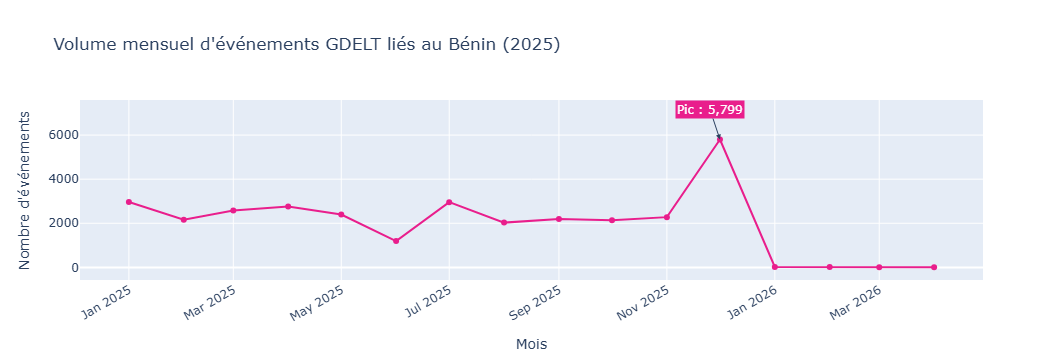

Mois le plus actif : 2025-12 (5,799 événements)
Mois le plus calme : 2026-04


In [6]:
monthly_vol = df.groupby('_month').size().reset_index(name='nb_evenements')
monthly_vol = monthly_vol.sort_values('_month')

fig = px.line(
    monthly_vol, x='_month', y='nb_evenements',
    markers=True,
    title='Volume mensuel d\'événements GDELT liés au Bénin (2025)',
    labels={'_month': 'Mois', 'nb_evenements': 'Nombre d\'événements'},
    color_discrete_sequence=['#e91e8c']
)
fig.update_layout(xaxis_tickangle=-30)

# Annoter le pic
peak = monthly_vol.loc[monthly_vol['nb_evenements'].idxmax()]
fig.add_annotation(
    x=peak['_month'], y=peak['nb_evenements'],
    text=f"Pic : {peak['nb_evenements']:,}",
    showarrow=True, arrowhead=2, bgcolor='#e91e8c', font=dict(color='white')
)
fig.show()

print(f"Mois le plus actif : {peak['_month']} ({peak['nb_evenements']:,} événements)")
print(f"Mois le plus calme : {monthly_vol.loc[monthly_vol['nb_evenements'].idxmin(), '_month']}")

---
## VIZ 2 — Répartition des types d'événements
**Question** : Le Bénin est-il surtout associé à des événements de coopération ou de conflit ?

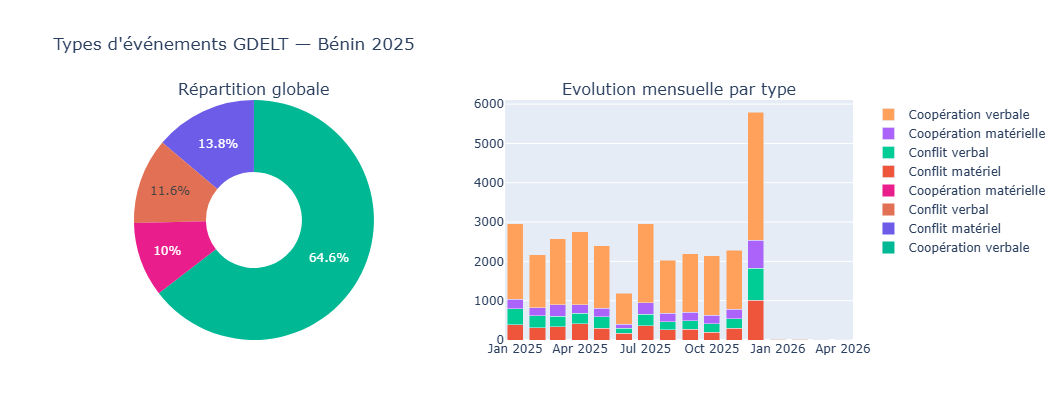

Coopération verbale            : 20,337  (64.6%)
Conflit matériel               :  4,354  (13.8%)
Conflit verbal                 :  3,648  (11.6%)
Coopération matérielle         :  3,165  (10.0%)


In [7]:
cat_counts = df['_category'].value_counts().reset_index()
cat_counts.columns = ['categorie', 'nombre']

# Camembert + barres côte à côte
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'pie'}, {'type': 'bar'}]],
    subplot_titles=['Répartition globale', 'Evolution mensuelle par type']
)

fig.add_trace(
    go.Pie(labels=cat_counts['categorie'], values=cat_counts['nombre'],
           hole=0.4, marker_colors=['#00b894','#6c5ce7','#e17055','#e91e8c']),
    row=1, col=1
)

monthly_cat = df.groupby(['_month', '_category']).size().reset_index(name='n')
for cat in monthly_cat['_category'].unique():
    sub = monthly_cat[monthly_cat['_category'] == cat]
    fig.add_trace(
        go.Bar(name=cat, x=sub['_month'], y=sub['n']),
        row=1, col=2
    )

fig.update_layout(
    title='Types d\'événements GDELT — Bénin 2025',
    barmode='stack', height=420, showlegend=True
)
fig.show()

total = cat_counts['nombre'].sum()
for _, row in cat_counts.iterrows():
    print(f"{row['categorie']:30s} : {row['nombre']:6,}  ({row['nombre']/total*100:.1f}%)")

---
## VIZ 3 — Evolution du ton médiatique
**Question** : Le regard des médias mondiaux sur le Bénin est-il plutôt positif ou négatif ? Evolue-t-il dans le temps ?

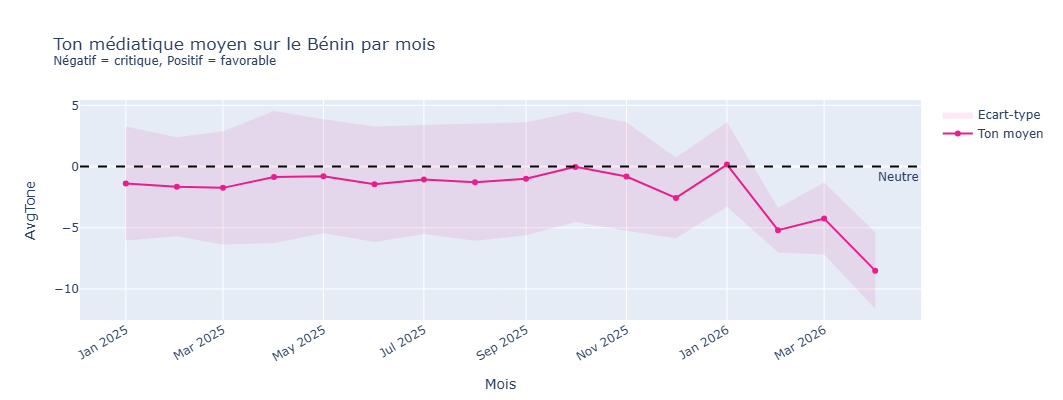

Ton moyen global  : -1.37
Mois le + positif : 2026-01 (0.16)
Mois le + négatif : 2026-04 (-8.51)


In [8]:
if COL_TONE:
    tone_monthly = df.groupby('_month')[COL_TONE].agg(['mean', 'median', 'std']).reset_index()
    tone_monthly.columns = ['mois', 'moyenne', 'mediane', 'ecart_type']
    tone_monthly = tone_monthly.sort_values('mois')

    fig = go.Figure()

    # Bande écart-type
    fig.add_trace(go.Scatter(
        x=list(tone_monthly['mois']) + list(tone_monthly['mois'])[::-1],
        y=list(tone_monthly['moyenne'] + tone_monthly['ecart_type']) +
          list((tone_monthly['moyenne'] - tone_monthly['ecart_type'])[::-1]),
        fill='toself', fillcolor='rgba(233,30,140,0.10)',
        line=dict(color='rgba(0,0,0,0)'), name='Ecart-type'
    ))

    fig.add_trace(go.Scatter(
        x=tone_monthly['mois'], y=tone_monthly['moyenne'],
        mode='lines+markers', name='Ton moyen',
        line=dict(color='#e91e8c', width=2)
    ))

    fig.add_hline(y=0, line_dash='dash', line_color='black',
                  annotation_text='Neutre', annotation_position='bottom right')

    fig.update_layout(
        title='Ton médiatique moyen sur le Bénin par mois<br><sup>Négatif = critique, Positif = favorable</sup>',
        xaxis_title='Mois', yaxis_title='AvgTone',
        xaxis_tickangle=-30, height=400
    )
    fig.show()

    print(f"Ton moyen global  : {df[COL_TONE].mean():.2f}")
    print(f"Mois le + positif : {tone_monthly.loc[tone_monthly['moyenne'].idxmax(), 'mois']} ({tone_monthly['moyenne'].max():.2f})")
    print(f"Mois le + négatif : {tone_monthly.loc[tone_monthly['moyenne'].idxmin(), 'mois']} ({tone_monthly['moyenne'].min():.2f})")

---
## VIZ 4 — Carte géographique des événements
**Question** : Où au Bénin les événements sont-ils localisés ? Y a-t-il des zones surreprésentées ?

24,837 événements géolocalisés dans le bounding box Bénin


C:\Users\hinde\AppData\Local\Temp\ipykernel_6800\980527233.py:20: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


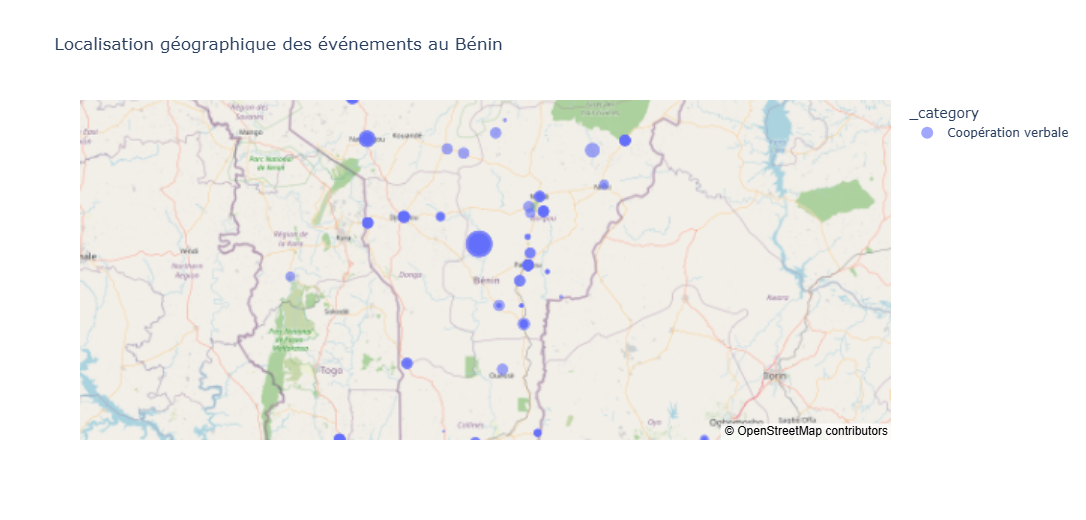

In [9]:
if COL_LAT and COL_LON:
    geo = df.dropna(subset=[COL_LAT, COL_LON]).copy()
    geo[COL_LAT] = pd.to_numeric(geo[COL_LAT], errors="coerce")
    geo[COL_LON] = pd.to_numeric(geo[COL_LON], errors="coerce")

    # Bounding box Bénin : 6.2°N - 12.4°N, 0.8°E - 3.8°E
    geo = geo[
        geo[COL_LAT].between(6.0, 12.5) &
        geo[COL_LON].between(0.5, 4.0)
    ]
    print(f"{len(geo):,} événements géolocalisés dans le bounding box Bénin")

    hover = {COL_LAT: False, COL_LON: False}
    if COL_TONE:      hover[COL_TONE]      = ":.2f"
    if COL_GOLDSTEIN: hover[COL_GOLDSTEIN] = ":.2f"

    # Guard : COL_MENTIONS doit être non-None ET présent dans geo
    size_col = COL_MENTIONS if (COL_MENTIONS and COL_MENTIONS in geo.columns) else None

    fig = px.scatter_mapbox(
        geo.head(8000),
        lat=COL_LAT, lon=COL_LON,
        color="_category" if "_category" in geo.columns else None,
        hover_name=COL_LOCATION if COL_LOCATION else None,
        hover_data=hover,
        size=size_col,
        size_max=20,
        zoom=6.5,
        center={"lat": 9.3, "lon": 2.3},
        mapbox_style="open-street-map",
        opacity=0.6, height=520,
        title="Localisation géographique des événements au Bénin"
    )
    fig.show()
else:
    print("Colonnes de coordonnées non trouvées — vérifie COL_LAT / COL_LON")


---
## VIZ 5 — Heatmap : ton médiatique par type d'événement et par mois
**Question** : Certains types d'événements sont-ils systématiquement couverts plus négativement ?

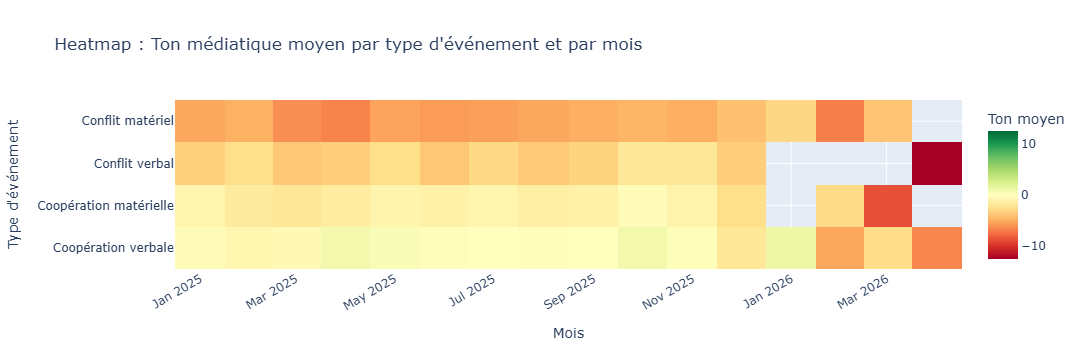

In [10]:
if COL_TONE and '_category' in df.columns:
    heatmap_data = df.groupby(['_month', '_category'])[COL_TONE].mean().reset_index()
    heatmap_pivot = heatmap_data.pivot(index='_category', columns='_month', values=COL_TONE)

    fig = px.imshow(
        heatmap_pivot,
        color_continuous_scale='RdYlGn',
        color_continuous_midpoint=0,
        title='Heatmap : Ton médiatique moyen par type d\'événement et par mois',
        labels=dict(x='Mois', y='Type d\'événement', color='Ton moyen'),
        aspect='auto', height=350
    )
    fig.update_xaxes(tickangle=-30)
    fig.show()

---
## VIZ 6 — Top acteurs mentionnés
**Question** : Qui sont les acteurs (personnes, institutions, pays) les plus présents dans les événements liés au Bénin ?

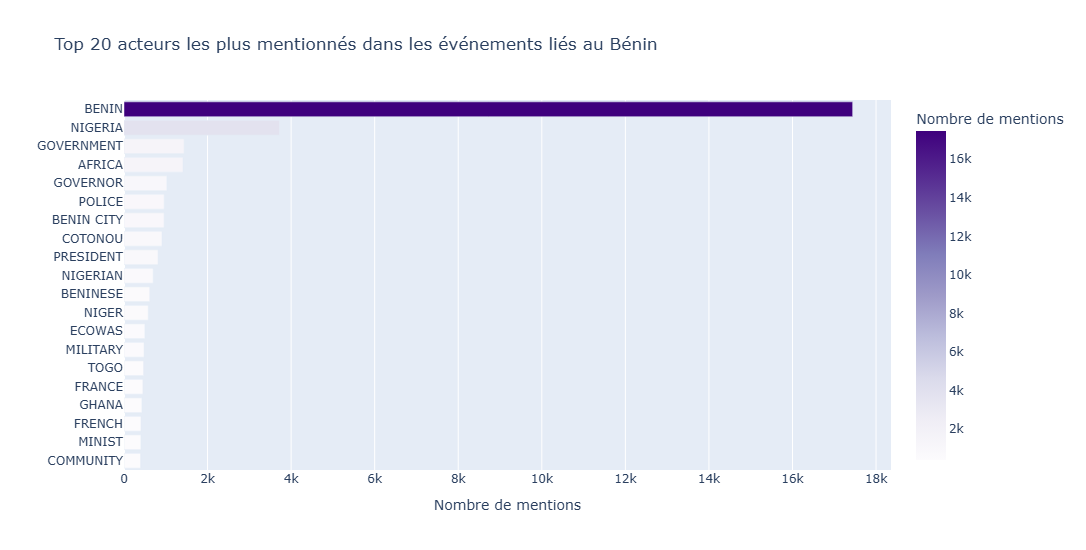

In [11]:
if COL_ACT1 or COL_ACT2:
    parts = []
    if COL_ACT1: parts.append(df[COL_ACT1].dropna().astype(str))
    if COL_ACT2: parts.append(df[COL_ACT2].dropna().astype(str))
    actors = pd.concat(parts)
    actors = actors[actors.str.strip().str.len() > 2]
    top = actors.value_counts().head(20).reset_index()
    top.columns = ["acteur", "mentions"]

    fig = px.bar(
        top.sort_values("mentions"),
        x="mentions", y="acteur",
        orientation="h",
        title="Top 20 acteurs les plus mentionnés dans les événements liés au Bénin",
        labels={"mentions": "Nombre de mentions", "acteur": ""},
        color="mentions", color_continuous_scale="Purples",
        height=550
    )
    fig.update_layout(showlegend=False)
    fig.show()


---
## VIZ 7 — Score Goldstein : stabilité par mois
**Question** : La perception de la stabilité du Bénin évolue-t-elle dans le temps ?

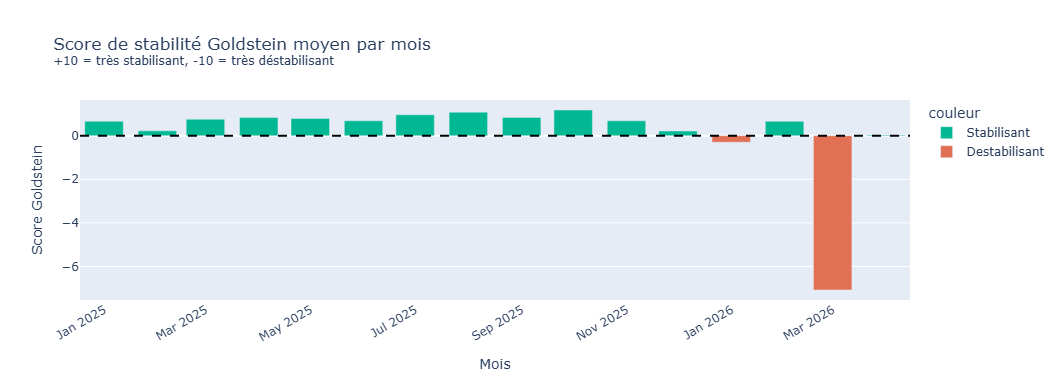

Score global : 0.68


In [12]:
if COL_GOLDSTEIN:
    df[COL_GOLDSTEIN] = pd.to_numeric(df[COL_GOLDSTEIN], errors='coerce')
    gold_monthly = df.groupby('_month')[COL_GOLDSTEIN].mean().reset_index()
    gold_monthly.columns = ['mois', 'goldstein_moyen']
    gold_monthly = gold_monthly.sort_values('mois')
    gold_monthly['couleur'] = gold_monthly['goldstein_moyen'].apply(
        lambda x: 'Stabilisant' if x >= 0 else 'Destabilisant'
    )

    fig = px.bar(
        gold_monthly, x='mois', y='goldstein_moyen',
        color='couleur',
        color_discrete_map={'Stabilisant': '#00b894', 'Destabilisant': '#e17055'},
        title='Score de stabilité Goldstein moyen par mois<br><sup>+10 = très stabilisant, -10 = très déstabilisant</sup>',
        labels={'mois': 'Mois', 'goldstein_moyen': 'Score Goldstein'},
        height=380
    )
    fig.add_hline(y=0, line_dash='dash', line_color='black')
    fig.update_layout(xaxis_tickangle=-30)
    fig.show()

    print(f"Score global : {df[COL_GOLDSTEIN].mean():.2f}")

---
## VIZ 8 — Mentions depuis GKG : thèmes dominants
**Question** : Quels thèmes (GDELT themes) sont les plus associés au Bénin dans la presse mondiale ?

In [13]:
# Charger gkg_clean
SQL_GKG = f"""
SELECT *
FROM `{PROJECT}.{DATASET}.gkg_clean`
LIMIT 50000
"""
gkg = bq(SQL_GKG)
print(f'gkg_clean : {len(gkg):,} lignes')
print('Colonnes :', list(gkg.columns))
gkg.head(3)

gkg_clean : 48,187 lignes
Colonnes : ['GKGRECORDID', 'DATE', 'SourceCommonName', 'DocumentIdentifier', 'V2Themes', 'V2Locations', 'V2Persons', 'V2Organizations', 'V2Tone', 'TranslationInfo', 'SharingImage', 'gkg_datetime', 'gkg_date', 'gkg_year_month', 'tone', 'tone_positive', 'tone_negative', 'tone_polarity', 'tone_activity', 'word_count', 'tone_category', 'source_language', 'is_translated', 'nb_themes', 'nb_persons', 'nb_organizations', 'nb_locations', 'is_rich_article']


,GKGRECORDID,DATE,SourceCommonName,DocumentIdentifier,V2Themes,V2Locations,V2Persons,V2Organizations,V2Tone,TranslationInfo,...,tone_activity,word_count,tone_category,source_language,is_translated,nb_themes,nb_persons,nb_organizations,nb_locations,is_rich_article
0,20250101003000-152,20250101003000,guardian.ng,https://guardian.ng/news/benin-protests-remark...,"ECON_DEBT,737;WB_1104_MACROECONOMIC_VULNERABIL...",1#Nigeria#NI#NI##10#8#NI#712;1#Benin#BN#BN##9....,"Olushegun Bakari,397;Mohamed Bazoum,921",None,"-5.14018691588785,2.33644859813084,7.476635514...",None,...,17.757009,200.0,Very Negative,eng,False,30,2,0,18,False
1,20250101003000-707,20250101003000,punchng.com,https://punchng.com/five-motorists-escape-deat...,"WOUND,1604;WOUND,2156;CRISISLEX_C03_WELLBEING_...","1#Benin#BN#BN##9.5#2.25#BN#139;5#Ogun State, O...","Abule Oko,2041;Seni Ogunyemi,341","Enforcement Agency,325;Volvo,1380;Volvo,1499","-9.27536231884058,0.869565217391304,10.1449275...",None,...,20.869565,332.0,Very Negative,eng,False,51,2,3,17,True
2,20250101003000-198,20250101003000,punchng.com,https://punchng.com/pdp-seeks-igs-intervention...,"TAX_FNCACT_CHIEF,1138;TAX_FNCACT_CHIEF,2677;TA...","5#Edo State, Edo, Nigeria#NI#NI37#191281#6.5#6...","Justice Daniel Okungbowa,1193;Justice Efe Ikpo...","House Of Assembly,528;House Of Assembly,1542;P...","-11.6822429906542,1.86915887850467,13.55140186...",None,...,18.224299,402.0,Very Negative,eng,False,100,6,4,6,True


Colonne thèmes : V2Themes
Séparateur détecté : ','


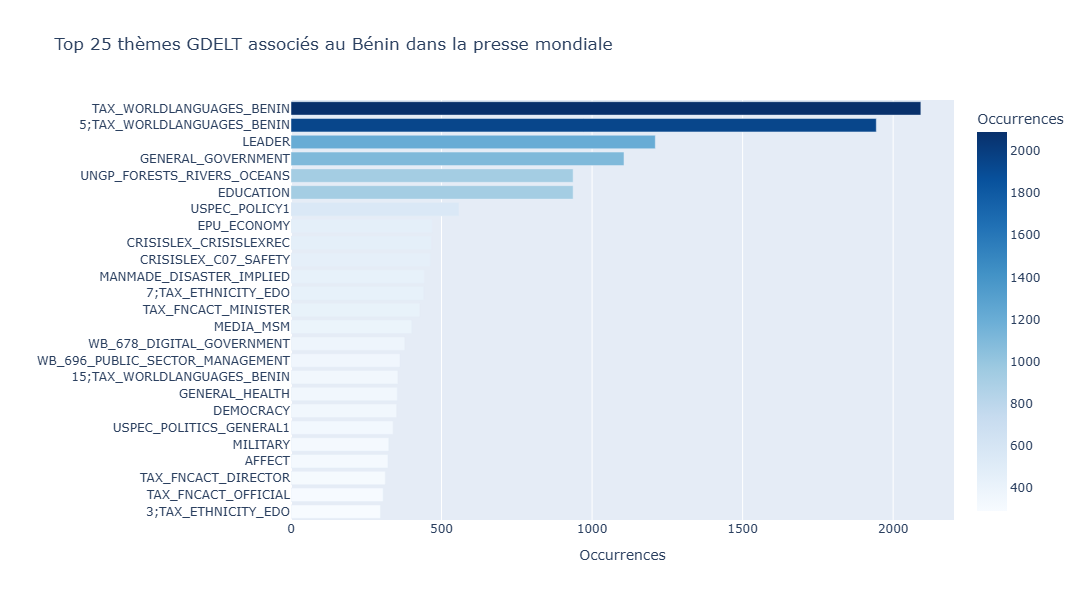

In [14]:
# Chercher la colonne themes
COL_THEMES = find_col(gkg, ["themes", "theme", "topic"])
print(f"Colonne thèmes : {COL_THEMES}")

if COL_THEMES:
    themes_clean = gkg[COL_THEMES].dropna().astype(str)
    themes_clean = themes_clean[themes_clean.str.strip() != ""]

    if len(themes_clean) == 0:
        print("Aucun thème trouvé dans la colonne.")
    else:
        # Détection robuste du séparateur sur un échantillon
        sample = themes_clean.head(100)
        sep = ";" if sample.str.contains(";").sum() > sample.str.contains(",").sum() else ","
        print(f"Séparateur détecté : {repr(sep)}")

        themes_series = themes_clean.str.split(sep).explode().str.strip()
        themes_series = themes_series[themes_series.str.len() > 2]
        top_themes = themes_series.value_counts().head(25).reset_index()
        top_themes.columns = ["theme", "count"]

        fig = px.bar(
            top_themes.sort_values("count"),
            x="count", y="theme", orientation="h",
            title="Top 25 thèmes GDELT associés au Bénin dans la presse mondiale",
            labels={"count": "Occurrences", "theme": ""},
            color="count", color_continuous_scale="Blues",
            height=600
        )
        fig.update_layout(showlegend=False)
        fig.show()


---
## Synthèse des insights préliminaires

In [15]:
print("=" * 65)
print("BENIN INSIGHTS — RESUME EXPLORATION")
print("=" * 65)
_min = df["_date"].min() if "_date" in df.columns else None
_max = df["_date"].max() if "_date" in df.columns else None
if pd.notna(_min) and pd.notna(_max):
    print(f"Periode        : {_min.date()} → {_max.date()}")
else:
    print("Periode        : N/A")
print(f"Total evenem.  : {len(df):,}")
if COL_TONE:      print(f"Ton moyen      : {df[COL_TONE].mean():.2f}")
if COL_GOLDSTEIN: print(f"Goldstein moy. : {df[COL_GOLDSTEIN].mean():.2f}")
if "_category" in df.columns:
    mode_val = df["_category"].mode()
    print(f"Type dominant  : {mode_val[0] if len(mode_val) > 0 else 'N/A'}")
print()
print("→ Complète cette section avec tes vraies observations")
print("  pour nourrir le resume_une_page.md")


BENIN INSIGHTS — RESUME EXPLORATION
Periode        : 2025-01-01 → 2026-04-16
Total evenem.  : 31,504
Ton moyen      : -1.37
Goldstein moy. : 0.68
Type dominant  : Coopération verbale

→ Complète cette section avec tes vraies observations
  pour nourrir le resume_une_page.md
